# PRAICP-1000-IndiSignLang — Data Preparation
**DataMites Project PR-0019 — Indian Sign Language Recognition**

## 1. Setup & Path Configuration

In [1]:
import os
import shutil
from collections import defaultdict

from PIL import Image
import matplotlib.pyplot as plt

# ---- EDIT THIS to match your folder location ----
DATA_DIR = r"G:\Datamites\Projects_datamites@2\PRAICP-1000-IndiSignLang\Data"
OUTPUT_DIR = r"G:\Datamites\Projects_datamites@2\PRAICP-1000-IndiSignLang\Split_Data"

print("Data folder exists:", os.path.exists(DATA_DIR))


Data folder exists: True


## 2. Inventory — Count Images per Class

In [2]:
VALID_EXT = ('.jpg', '.jpeg', '.png')

counts = {}
for folder in sorted(os.listdir(DATA_DIR)):
    folder_path = os.path.join(DATA_DIR, folder)
    if os.path.isdir(folder_path):
        images = [f for f in os.listdir(folder_path) if f.lower().endswith(VALID_EXT)]
        counts[folder] = len(images)

for cls, count in counts.items():
    print(f"{cls}: {count} images")

print("\nTotal classes:", len(counts))
print("Total images:", sum(counts.values()))
print("Min class:", min(counts, key=counts.get), "->", min(counts.values()))
print("Max class:", max(counts, key=counts.get), "->", max(counts.values()))


A: 242 images
B: 259 images
C: 247 images
D: 147 images
E: 243 images
F: 226 images
G: 241 images
H: 116 images
I: 179 images
K: 245 images
L: 182 images
M: 235 images
N: 237 images
O: 229 images
P: 234 images
Q: 216 images
R: 211 images
S: 229 images
T: 216 images
U: 135 images
V: 122 images
W: 128 images
X: 202 images
Y: 251 images

Total classes: 24
Total images: 4972
Min class: H -> 116
Max class: B -> 259


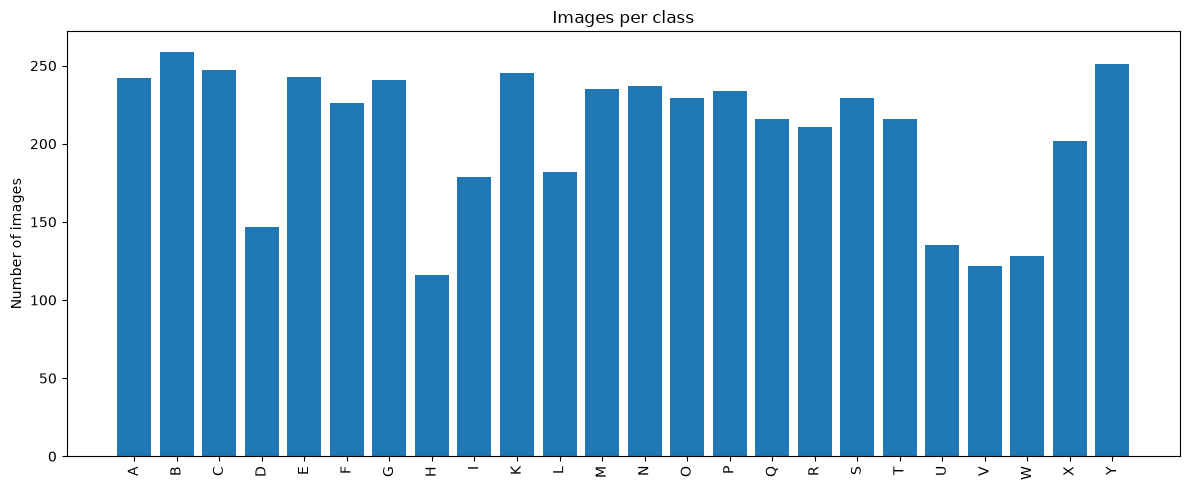

In [3]:
# Bar chart of class distribution — quick visual check for imbalance
plt.figure(figsize=(12, 5))
plt.bar(counts.keys(), counts.values())
plt.xticks(rotation=90)
plt.ylabel("Number of images")
plt.title("Images per class")
plt.tight_layout()
plt.show()


## 3. Check Image Properties (size, mode, corrupt files)

This scans every image, records its dimensions, and flags any file that fails to open
(corrupt / truncated images are common in scraped or exported datasets).

In [4]:
sizes = defaultdict(int)
corrupt_files = []

for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(VALID_EXT):
            continue
        fpath = os.path.join(cls_path, fname)
        try:
            with Image.open(fpath) as img:
                sizes[img.size] += 1
        except Exception as e:
            corrupt_files.append((fpath, str(e)))

print("Unique image dimensions found:")
for size, count in sorted(sizes.items(), key=lambda x: -x[1]):
    print(f"  {size}: {count} images")

print(f"\nCorrupt / unreadable files: {len(corrupt_files)}")
for f, err in corrupt_files[:10]:
    print(" -", f, "->", err)


Unique image dimensions found:
  (640, 480): 3963 images
  (1920, 1088): 830 images
  (1088, 1920): 179 images

Corrupt / unreadable files: 0


## 4. Visual Check — Sample Images per Class

Few images from each class to confirm labels look correct and to see how much
natural variation exists (lighting, hand position, background).

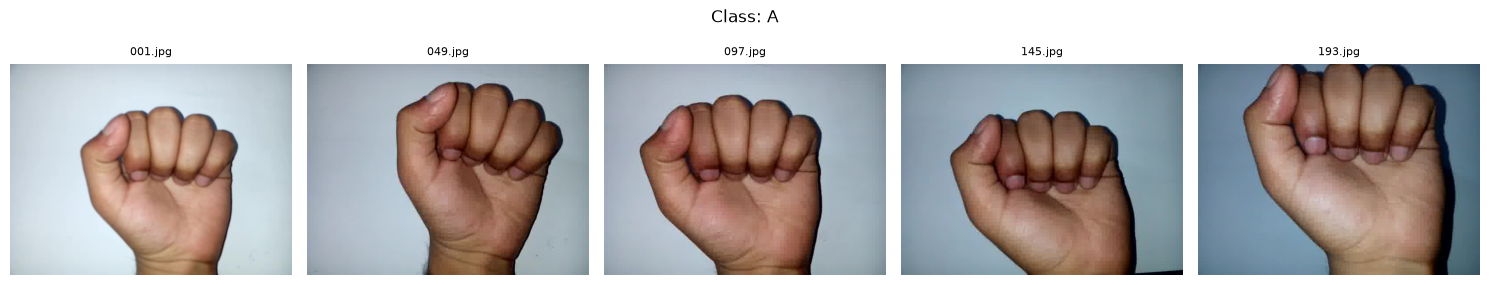

In [5]:
def show_class_samples(cls_name, n=5):
    cls_path = os.path.join(DATA_DIR, cls_name)
    images = sorted([f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)])
    step = max(1, len(images) // n)
    sample = images[::step][:n]

    fig, axes = plt.subplots(1, len(sample), figsize=(3 * len(sample), 3))
    if len(sample) == 1:
        axes = [axes]
    for ax, fname in zip(axes, sample):
        img = Image.open(os.path.join(cls_path, fname))
        ax.imshow(img)
        ax.set_title(fname, fontsize=8)
        ax.axis('off')
    fig.suptitle(f"Class: {cls_name}")
    plt.tight_layout()
    plt.show()

# Change this to inspect any class, e.g. show_class_samples('B')
show_class_samples('A')


## 5. Subsample + Sequential Train/Val/Test Split

**Why sequential, not random?**
Images within each class folder are sequential frames from one continuous recording
session — adjacent frames are near-duplicates. A random split would put near-identical
images in both train and test (data leakage), inflating accuracy artificially.

**Approach:**
- Keep every Nth frame per class (`SUBSAMPLE_EVERY`) to reduce redundancy
- Split remaining frames **in filename order**: first 70% -> train, next 15% -> val, last 15% -> test
- This means test images come from a different part of the recording than training images

In [6]:
SUBSAMPLE_EVERY = 4      # keep every 4th image — adjust based on Step 2 counts
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
# remaining ~0.15 goes to test

for split in ["train", "val", "test"]:
    os.makedirs(os.path.join(OUTPUT_DIR, split), exist_ok=True)

split_summary = []

for cls in sorted(os.listdir(DATA_DIR)):
    cls_path = os.path.join(DATA_DIR, cls)
    if not os.path.isdir(cls_path):
        continue

    images = sorted([f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)])
    subsampled = images[::SUBSAMPLE_EVERY]

    n = len(subsampled)
    train_end = int(n * TRAIN_RATIO)
    val_end = train_end + int(n * VAL_RATIO)

    splits = {
        "train": subsampled[:train_end],
        "val": subsampled[train_end:val_end],
        "test": subsampled[val_end:]
    }

    for split_name, file_list in splits.items():
        split_cls_dir = os.path.join(OUTPUT_DIR, split_name, cls)
        os.makedirs(split_cls_dir, exist_ok=True)
        for fname in file_list:
            src = os.path.join(cls_path, fname)
            dst = os.path.join(split_cls_dir, fname)
            shutil.copy2(src, dst)

    split_summary.append((cls, len(images), n, len(splits['train']), len(splits['val']), len(splits['test'])))
    print(f"{cls}: {len(images)} raw -> {n} after subsampling "
          f"-> train {len(splits['train'])}, val {len(splits['val'])}, test {len(splits['test'])}")

print("\nDone. Split data saved to:", OUTPUT_DIR)


A: 242 raw -> 61 after subsampling -> train 42, val 9, test 10
B: 259 raw -> 65 after subsampling -> train 45, val 9, test 11
C: 247 raw -> 62 after subsampling -> train 43, val 9, test 10
D: 147 raw -> 37 after subsampling -> train 25, val 5, test 7
E: 243 raw -> 61 after subsampling -> train 42, val 9, test 10
F: 226 raw -> 57 after subsampling -> train 39, val 8, test 10
G: 241 raw -> 61 after subsampling -> train 42, val 9, test 10
H: 116 raw -> 29 after subsampling -> train 20, val 4, test 5
I: 179 raw -> 45 after subsampling -> train 31, val 6, test 8
K: 245 raw -> 62 after subsampling -> train 43, val 9, test 10
L: 182 raw -> 46 after subsampling -> train 32, val 6, test 8
M: 235 raw -> 59 after subsampling -> train 41, val 8, test 10
N: 237 raw -> 60 after subsampling -> train 42, val 9, test 9
O: 229 raw -> 58 after subsampling -> train 40, val 8, test 10
P: 234 raw -> 59 after subsampling -> train 41, val 8, test 10
Q: 216 raw -> 54 after subsampling -> train 37, val 8, test 

## 6. Verify the Split Output

In [7]:
for split in ["train", "val", "test"]:
    split_path = os.path.join(OUTPUT_DIR, split)
    total = 0
    n_classes = 0
    for cls in sorted(os.listdir(split_path)):
        cls_path = os.path.join(split_path, cls)
        if os.path.isdir(cls_path):
            n_imgs = len([f for f in os.listdir(cls_path) if f.lower().endswith(VALID_EXT)])
            total += n_imgs
            n_classes += 1
    print(f"{split}: {n_classes} classes, {total} images")


train: 24 classes, 864 images
val: 24 classes, 176 images
test: 24 classes, 212 images
